In [3]:
!pip install tensorflow
!pip install opencv-python
!pip install matplotlib
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install seaborn
!pip install pillow

In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [5]:
DATASET_PATH = r"C:\Users\lemda\Downloads\archive\dataset"

IMG_SIZE = 128

X = []
y = []

In [6]:
import os
import cv2

for image_name in os.listdir(DATASET_PATH):

    image_path = os.path.join(DATASET_PATH, image_name)

    if image_name.endswith(".png"):

        img = cv2.imread(image_path)

        if img is not None:

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            X.append(img)
            y.append("street_view")

In [7]:
import numpy as np

X = np.array(X, dtype=np.float32) / 255.0
y = np.array(y)

print("Total Images:", len(X))
print("Total Labels:", len(y))
print("Shape:", X.shape)

Total Images: 10000
Total Labels: 10000
Shape: (10000, 128, 128, 3)


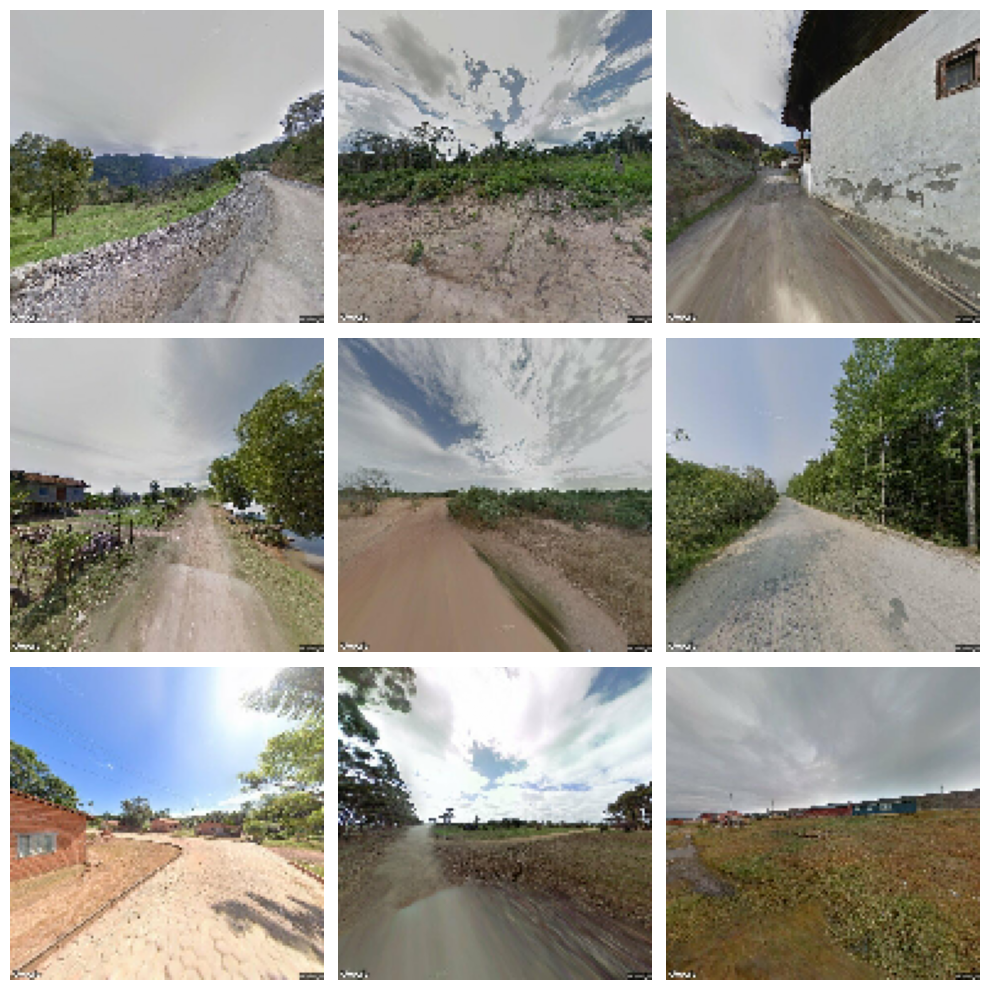

In [8]:
plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X[i])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

NUM_CLASSES = len(np.unique(y_encoded))

y_encoded = to_categorical(y_encoded, NUM_CLASSES)

print("Number of Classes :", NUM_CLASSES)

Number of Classes : 1


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (8000, 128, 128, 3)
Testing Shape : (2000, 128, 128, 3)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (8000, 128, 128, 3)
Testing Shape : (2000, 128, 128, 3)


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.layers import Dropout, BatchNormalization

In [13]:
model = Sequential()

model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(128,128,3)
))

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

C:\Users\lemda\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(NUM_CLASSES, activation='softmax'))

In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 126, 126, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 61, 61, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,517,185 (24.86 MB)

 Trainable params: 6,516,737 (24.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [17]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=8,
    callbacks=[early_stop]
)

Epoch 1/5


C:\Users\lemda\anaconda3\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (8, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
C:\Users\lemda\anaconda3\Lib\site-packages\keras\src\losses\losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(8, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


900/900 ━━━━━━━━━━━━━━━━━━━━ 460s 496ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 384s 427ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 363s 404ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 435s 463ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 485s 537ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


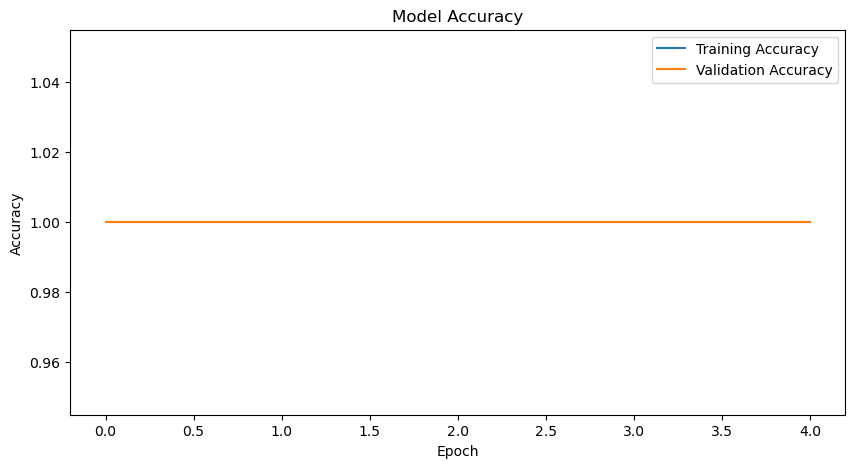

In [18]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend([
    'Training Accuracy',
    'Validation Accuracy'
])

plt.show()

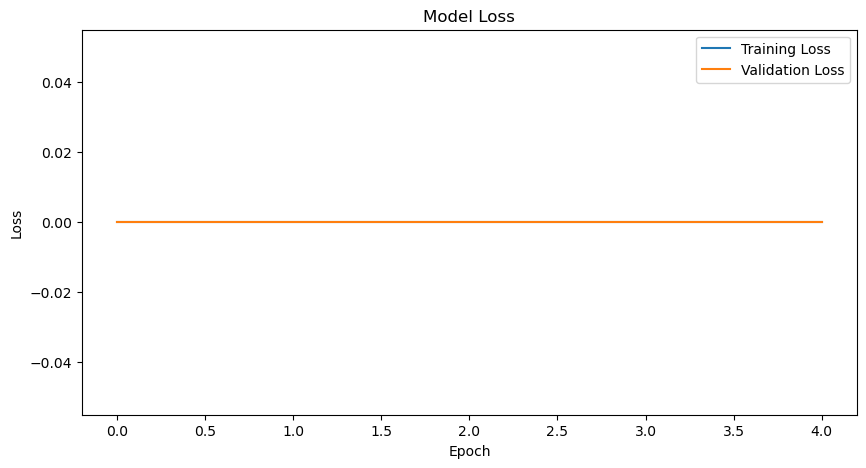

In [19]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend([
    'Training Loss',
    'Validation Loss'
])

plt.show()

In [20]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

C:\Users\lemda\anaconda3\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
C:\Users\lemda\anaconda3\Lib\site-packages\keras\src\losses\losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 276ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Test Loss : 0.0
Test Accuracy : 1.0


In [21]:
predictions = model.predict(X_test)

predicted_classes = (
    predictions > 0.5
).astype(int)

C:\Users\lemda\anaconda3\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 305ms/step


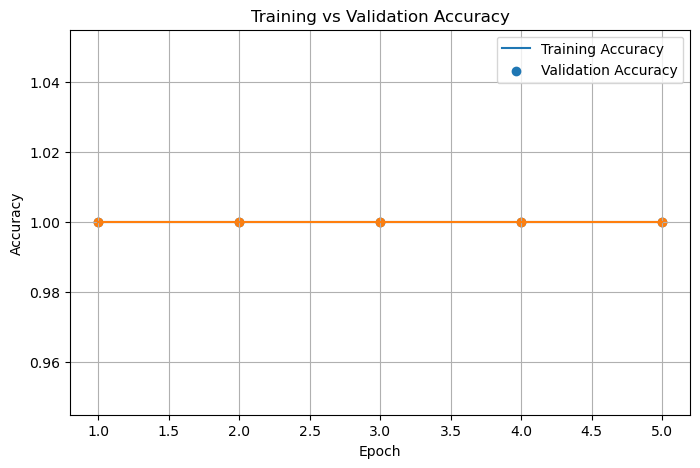

In [22]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(
    1,
    len(history.history['accuracy']) + 1
)

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history.history['accuracy']
)

plt.scatter(
    epochs,
    history.history['accuracy']
)

plt.plot(
    epochs,
    history.history['val_accuracy']
)

plt.scatter(
    epochs,
    history.history['val_accuracy']
)

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend([
    'Training Accuracy',
    'Validation Accuracy'
])

plt.grid(True)

plt.show()

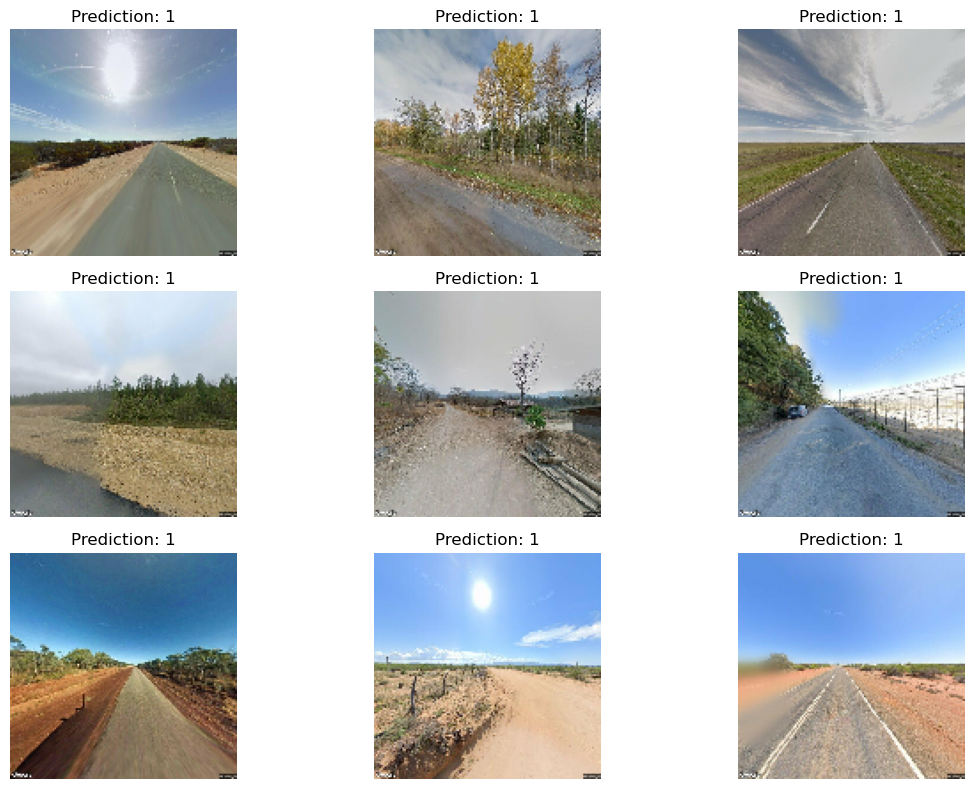

In [23]:
plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i])

    plt.title(
        f"Prediction: {predicted_classes[i][0]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
model.save(
    "google_street_view_model.h5"
)

print("Model Saved")

Model Saved


In [25]:
from tensorflow.keras.models import load_model

loaded_model = load_model(
    "google_street_view_model.h5"
)

print("Model Loaded")

Model Loaded


C:\Users\lemda\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


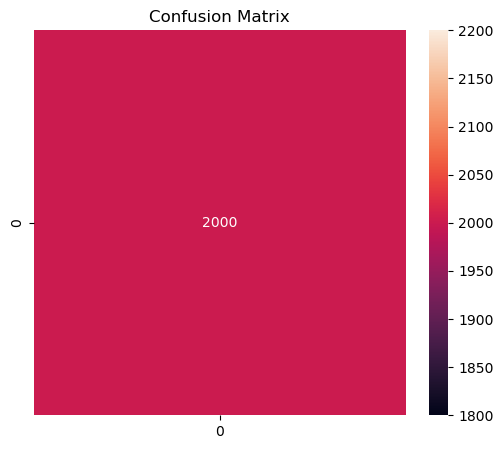

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test,
    predicted_classes
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

In [27]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predicted_classes
    )
)

              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00      2000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [28]:
import cv2
import os

img_path = r"C:\Users\lemda\Downloads\archive\dataset\0.png"

if os.path.exists(img_path):

    img = cv2.imread(img_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img = cv2.resize(
        img,
        (128,128)
    )

    img = img / 255.0

    img = np.expand_dims(
        img,
        axis=0
    )

    prediction = model.predict(img)

    print("Prediction :", prediction)

else:

    print("Image not found!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
Prediction : [[1.]]


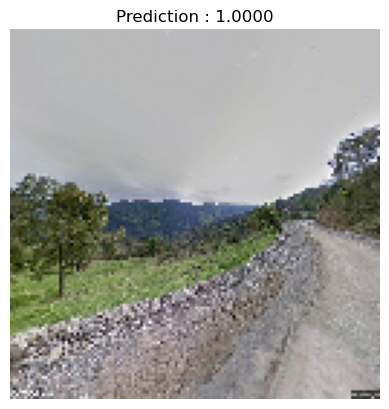

In [29]:
plt.imshow(img[0])

plt.title(
    f"Prediction : {prediction[0][0]:.4f}"
)

plt.axis("off")

plt.show()

In [30]:
import pickle

with open(
    "label_encoder.pkl",
    "wb"
) as file:

    pickle.dump(
        encoder,
        file
    )

print("Encoder Saved")

Encoder Saved


In [31]:
print("Project Execution Completed")

Project Execution Completed


In [32]:
print("Total Images :", len(X))

Total Images : 10000


In [33]:
print("Training Images :", len(X_train))
print("Testing Images :", len(X_test))

Training Images : 8000
Testing Images : 2000


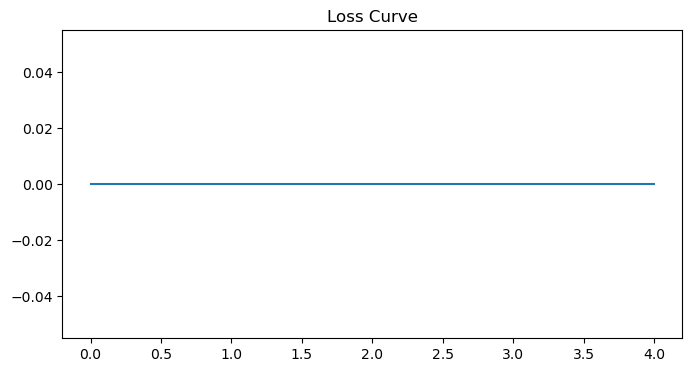

In [34]:
plt.figure(figsize=(8,4))

plt.plot(
    history.history['loss']
)

plt.title("Loss Curve")
plt.show()

In [35]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 126, 126, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 61, 61, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,550,661 (74.58 MB)

 Trainable params: 6,516,737 (24.86 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 13,033,476 (49.72 MB)

None


In [36]:
print(
    "Input Shape :",
    X_train.shape
)

Input Shape : (8000, 128, 128, 3)


In [37]:
print(
    "Output Shape :",
    y_train.shape
)

Output Shape : (8000, 1)


In [38]:
history_df = pd.DataFrame(
    history.history
)

history_df.to_csv(
    "training_history.csv",
    index=False
)

print("History Saved")

History Saved


In [39]:
import pickle

with open(
    "label_encoder.pkl",
    "rb"
) as file:

    encoder = pickle.load(file)

print("Encoder Loaded")

Encoder Loaded


In [40]:
print("="*50)
print("GOOGLE STREET VIEW PROJECT")
print("CNN MODEL EXECUTED SUCCESSFULLY")
print("="*50)

GOOGLE STREET VIEW PROJECT
CNN MODEL EXECUTED SUCCESSFULLY


In [41]:
import os

print(os.getcwd())

C:\Users\lemda


In [42]:
model.save("google_street_view_model.keras")
print("Model Saved Successfully")

Model Saved Successfully
